In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path("/Users/nischayaggarwal/Internship 1/data/Processed")
OUT_DIR = Path("/Users/nischayaggarwal/Internship 1/reports")
CHART_DIR = OUT_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

RF_ANNUAL = 0.065
RF_DAILY = RF_ANNUAL / 252

def savefig(name):
    path = CHART_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved: {path}")
    plt.show()

In [2]:
fund_master = pd.read_csv(DATA_DIR / "clean_fund_master.csv")
nav = pd.read_csv(DATA_DIR / "clean_nav_history.csv")
transactions = pd.read_csv(DATA_DIR / "clean_investor_transactions.csv")
portfolio = pd.read_csv(DATA_DIR / "clean_portfolio_holdings.csv")

scorecard_path = DATA_DIR / "performance_outputs" / "fund_scorecard.csv"
if scorecard_path.exists():
    scorecard = pd.read_csv(scorecard_path)
else:
    scorecard = pd.read_csv(DATA_DIR / "clean_scheme_performance.csv")

nav["date"] = pd.to_datetime(nav["date"])
transactions["date"] = pd.to_datetime(transactions["date"])
portfolio["portfolio_date"] = pd.to_datetime(portfolio["portfolio_date"], errors="coerce")

meta_cols = ["amfi_code", "scheme_name", "fund_house", "category", "sub_category", "risk_category", "expense_ratio_pct"]
nav = nav.merge(fund_master[meta_cols], on="amfi_code", how="left")

transactions = transactions.merge(
    fund_master[["amfi_code", "scheme_name", "fund_house", "category", "sub_category", "risk_category"]],
    on="amfi_code",
    how="left"
)

portfolio = portfolio.merge(
    fund_master[["amfi_code", "scheme_name", "fund_house", "category", "sub_category"]],
    on="amfi_code",
    how="left"
)

print("Fund master:", fund_master.shape)
print("NAV:", nav.shape)
print("Transactions:", transactions.shape)
print("Portfolio:", portfolio.shape)
print("Scorecard:", scorecard.shape)

Fund master: (40, 15)
NAV: (46000, 9)
Transactions: (32778, 19)
Portfolio: (322, 12)
Scorecard: (40, 22)


In [3]:
nav = nav.sort_values(["amfi_code", "date"]).copy()
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav[["amfi_code", "scheme_name", "date", "nav", "daily_return"]].head()

,amfi_code,scheme_name,date,nav,daily_return
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-03,520.4608,NaN
1,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-04,515.0971,-0.010306
2,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-05,521.7239,0.012865
3,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-06,515.7880,-0.011377
4,100016,HDFC Top 100 Fund - Regular Plan - Growth,2022-01-07,515.1639,-0.001210


In [4]:
var_rows = []

for code, g in nav.groupby("amfi_code"):
    r = g["daily_return"].dropna()
    latest = g.iloc[-1]

    var_95 = np.percentile(r, 5) if len(r) else np.nan
    cvar_95 = r[r <= var_95].mean() if len(r) else np.nan

    var_rows.append({
        "amfi_code": code,
        "scheme_name": latest["scheme_name"],
        "fund_house": latest["fund_house"],
        "category": latest["category"],
        "sub_category": latest["sub_category"],
        "risk_category": latest["risk_category"],
        "var_95_daily_pct": var_95 * 100 if pd.notna(var_95) else np.nan,
        "cvar_95_daily_pct": cvar_95 * 100 if pd.notna(cvar_95) else np.nan,
        "observations": len(r)
    })

var_cvar = pd.DataFrame(var_rows).sort_values("var_95_daily_pct")
var_cvar.to_csv(OUT_DIR / "var_cvar_report.csv", index=False)
var_cvar.head(10)

,amfi_code,scheme_name,fund_house,category,sub_category,risk_category,var_95_daily_pct,cvar_95_daily_pct,observations
22,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,Small Cap,Very High,-2.685944,-3.238412,1149
17,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Equity,Small Cap,Very High,-2.618842,-3.166729,1149
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Small Cap,Very High,-2.602125,-3.245906,1149
11,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Equity,Small Cap,Very High,-2.543811,-3.230407,1149
21,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Small Cap,Very High,-2.450705,-3.059526,1149
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,Small Cap,Very High,-2.348307,-3.103625,1149
7,102886,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Equity,Mid Cap,High,-1.922028,-2.325086,1149
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,Mid Cap,High,-1.903354,-2.345576,1149
25,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,Mid Cap,High,-1.889179,-2.434207,1149
16,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,Mid Cap,High,-1.848028,-2.426006,1149


Saved: /Users/nischayaggarwal/Internship 1/reports/rolling_sharpe_chart.png


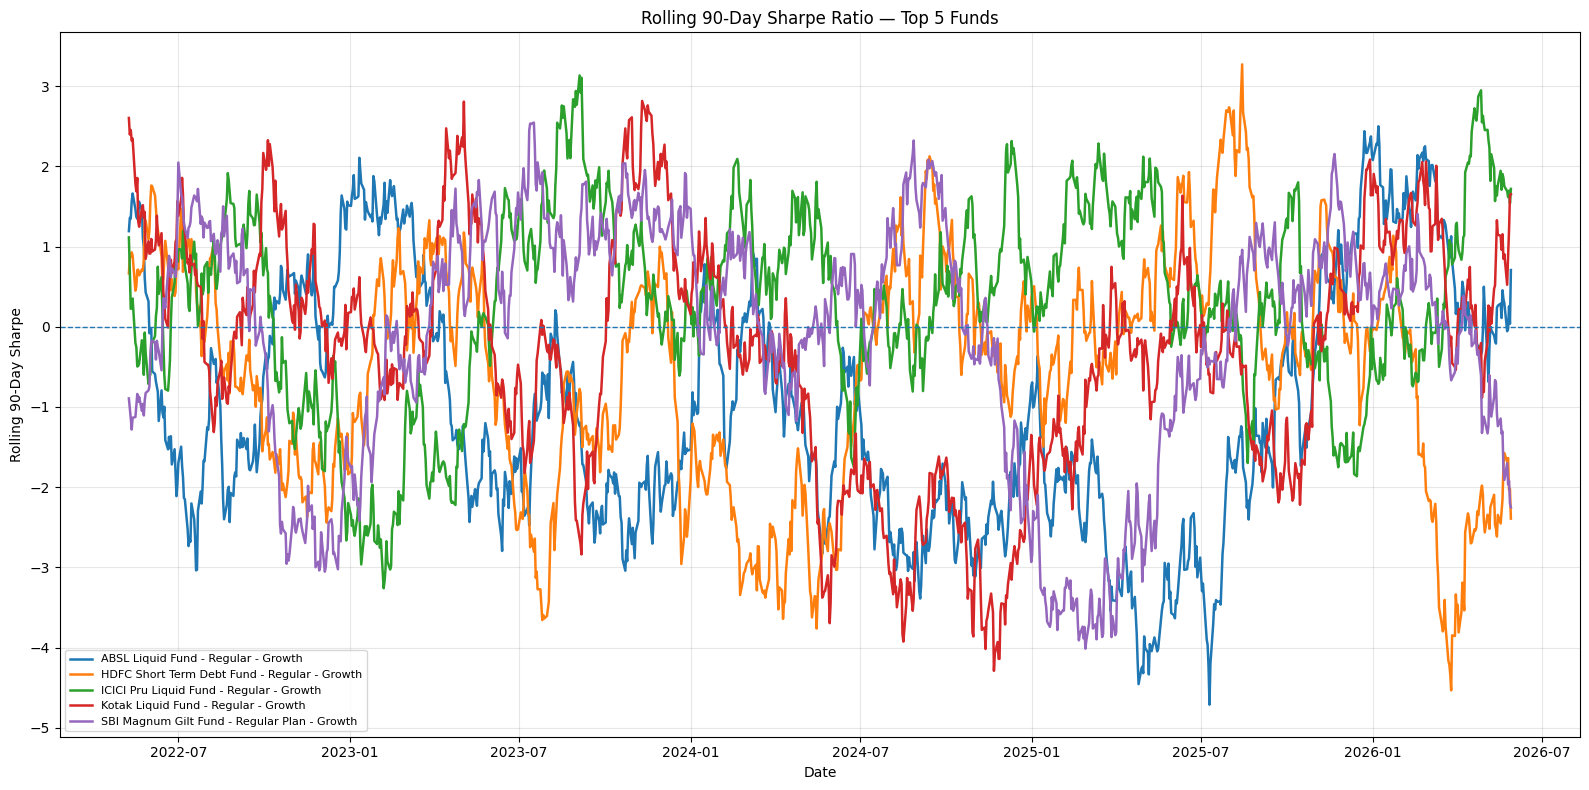

In [5]:
if "fund_score_0_100" in scorecard.columns:
    top5_codes = scorecard.sort_values("fund_score_0_100", ascending=False).head(5)["amfi_code"].tolist()
elif "sharpe_ratio" in scorecard.columns:
    top5_codes = scorecard.sort_values("sharpe_ratio", ascending=False).head(5)["amfi_code"].tolist()
else:
    top5_codes = nav["amfi_code"].drop_duplicates().head(5).tolist()

rolling_parts = []

for code in top5_codes:
    g = nav[nav["amfi_code"] == code].sort_values("date").copy()
    g["rolling_90d_sharpe"] = (
        (g["daily_return"].rolling(90).mean() - RF_DAILY)
        / g["daily_return"].rolling(90).std()
    ) * np.sqrt(252)

    rolling_parts.append(g[["amfi_code", "scheme_name", "date", "rolling_90d_sharpe"]])

rolling_sharpe = pd.concat(rolling_parts, ignore_index=True)
rolling_sharpe.to_csv(OUT_DIR / "rolling_90day_sharpe.csv", index=False)

plt.figure(figsize=(16, 8))
for name, g in rolling_sharpe.dropna().groupby("scheme_name"):
    plt.plot(g["date"], g["rolling_90d_sharpe"], label=name[:45], linewidth=1.8)

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Rolling 90-Day Sharpe Ratio — Top 5 Funds")
plt.xlabel("Date")
plt.ylabel("Rolling 90-Day Sharpe")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)

savefig("rolling_sharpe_chart.png")

In [6]:
tx = transactions.copy()
tx["first_transaction_date"] = tx.groupby("investor_id")["date"].transform("min")
tx["cohort_year"] = tx["first_transaction_date"].dt.year

sip_tx = tx[tx["transaction_type"].astype(str).str.lower().eq("sip")].copy()

avg_sip = sip_tx.groupby("cohort_year")["amount"].mean().rename("avg_sip_amount")

total_invested = (
    tx[tx["transaction_type"].isin(["SIP", "Lumpsum"])]
    .groupby("cohort_year")["amount"]
    .sum()
    .rename("total_invested")
)

pref = (
    tx[tx["transaction_type"].isin(["SIP", "Lumpsum"])]
    .groupby(["cohort_year", "scheme_name"])["amount"]
    .sum()
    .reset_index()
    .sort_values(["cohort_year", "amount"], ascending=[True, False])
    .groupby("cohort_year")
    .head(1)
    .rename(columns={"scheme_name": "top_fund_preference", "amount": "top_fund_amount"})
)

cohort = pd.DataFrame({"cohort_year": sorted(tx["cohort_year"].dropna().unique())})
cohort = cohort.merge(avg_sip, on="cohort_year", how="left")
cohort = cohort.merge(total_invested, on="cohort_year", how="left")
cohort = cohort.merge(pref, on="cohort_year", how="left")

investor_counts = tx.groupby("cohort_year")["investor_id"].nunique().rename("investor_count").reset_index()
cohort = cohort.merge(investor_counts, on="cohort_year", how="left")

cohort.to_csv(OUT_DIR / "investor_cohort_analysis.csv", index=False)
cohort

,cohort_year,avg_sip_amount,total_invested,top_fund_preference,top_fund_amount,investor_count
0,2024,10996.885825,2258062304,Axis Small Cap Fund - Regular - Growth,65025476,4803
1,2025,13505.209581,18992635,Axis Midcap Fund - Regular - Growth,1283425,197


Saved: /Users/nischayaggarwal/Internship 1/reports/investor_cohort_total_invested.png


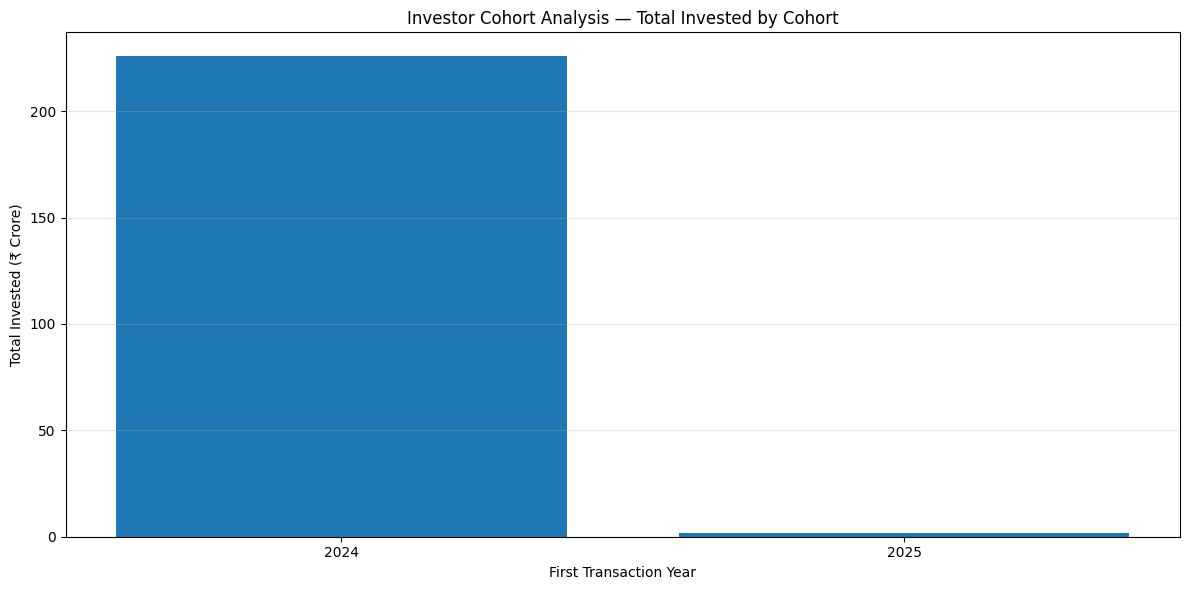

In [7]:
plt.figure(figsize=(12, 6))
plt.bar(cohort["cohort_year"].astype(str), cohort["total_invested"] / 1e7)
plt.xlabel("First Transaction Year")
plt.ylabel("Total Invested (₹ Crore)")
plt.title("Investor Cohort Analysis — Total Invested by Cohort")
plt.grid(axis="y", alpha=0.3)
savefig("investor_cohort_total_invested.png")

In [8]:
sip_sorted = sip_tx.sort_values(["investor_id", "date"]).copy()
sip_counts = sip_sorted.groupby("investor_id").size().rename("sip_transaction_count")

eligible_investors = sip_counts[sip_counts >= 6].index
sip_eligible = sip_sorted[sip_sorted["investor_id"].isin(eligible_investors)].copy()

sip_eligible["previous_sip_date"] = sip_eligible.groupby("investor_id")["date"].shift(1)
sip_eligible["gap_days"] = (sip_eligible["date"] - sip_eligible["previous_sip_date"]).dt.days

continuity = (
    sip_eligible.groupby("investor_id")
    .agg(
        sip_transaction_count=("date", "count"),
        avg_gap_days=("gap_days", "mean"),
        max_gap_days=("gap_days", "max"),
        first_sip_date=("date", "min"),
        last_sip_date=("date", "max"),
        total_sip_amount=("amount", "sum")
    )
    .reset_index()
)

continuity["status"] = np.where(continuity["avg_gap_days"] > 35, "at-risk", "regular")
continuity.to_csv(OUT_DIR / "sip_continuity.csv", index=False)

continuity_summary = pd.DataFrame({
    "metric": ["eligible_sip_investors", "regular_investors", "at_risk_investors", "at_risk_rate_pct", "avg_gap_days_overall"],
    "value": [
        len(continuity),
        (continuity["status"] == "regular").sum(),
        (continuity["status"] == "at-risk").sum(),
        ((continuity["status"] == "at-risk").mean() * 100) if len(continuity) else np.nan,
        continuity["avg_gap_days"].mean()
    ]
})

continuity_summary.to_csv(OUT_DIR / "sip_continuity_summary.csv", index=False)
continuity_summary

,metric,value
0,eligible_sip_investors,1362.000000
1,regular_investors,30.000000
2,at_risk_investors,1332.000000
3,at_risk_rate_pct,97.797357
4,avg_gap_days_overall,64.889132


Saved: /Users/nischayaggarwal/Internship 1/reports/sip_continuity_status.png


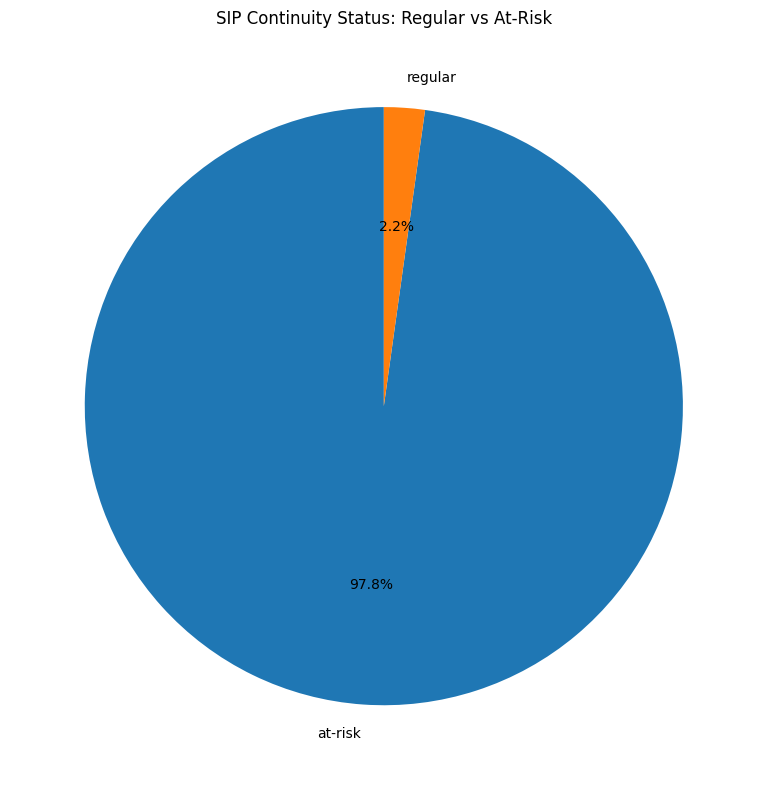

In [9]:
plt.figure(figsize=(8, 8))

if len(continuity):
    status_counts = continuity["status"].value_counts()
    plt.pie(status_counts.values, labels=status_counts.index, autopct="%1.1f%%", startangle=90)
else:
    plt.text(0.5, 0.5, "No investors with 6+ SIP transactions", ha="center")

plt.title("SIP Continuity Status: Regular vs At-Risk")
savefig("sip_continuity_status.png")

In [11]:
rec_base = scorecard.copy()

# Add missing columns from fund_master
extra_cols = ["amfi_code", "scheme_name", "fund_house", "category", "sub_category", "risk_category"]

for col in extra_cols:
    if col not in rec_base.columns and col in fund_master.columns:
        rec_base = rec_base.merge(
            fund_master[["amfi_code", col]],
            on="amfi_code",
            how="left"
        )

if "sharpe_ratio" not in rec_base.columns and "sharpe" in rec_base.columns:
    rec_base["sharpe_ratio"] = rec_base["sharpe"]

def recommend_funds(risk_appetite="Moderate", top_n=3):
    risk_appetite = risk_appetite.lower().strip()
    risk_text = rec_base["risk_category"].astype(str).str.lower()

    if risk_appetite == "low":
        filtered = rec_base[risk_text.str.contains("low|moderate", regex=True, na=False)]
    elif risk_appetite == "moderate":
        filtered = rec_base[risk_text.str.contains("moderate|high", regex=True, na=False)]
    elif risk_appetite == "high":
        filtered = rec_base[risk_text.str.contains("high|very high", regex=True, na=False)]
    else:
        raise ValueError("risk_appetite must be Low, Moderate, or High")

    display_cols = [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "sub_category",
        "risk_category",
        "sharpe_ratio"
    ]

    if "fund_score_0_100" in rec_base.columns:
        display_cols.append("fund_score_0_100")

    # Keep only columns that actually exist
    display_cols = [col for col in display_cols if col in filtered.columns]

    return filtered.sort_values("sharpe_ratio", ascending=False)[display_cols].head(top_n)

recommend_funds("Moderate")

,amfi_code,scheme_name,fund_house,category,sub_category,risk_category,sharpe_ratio
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Large Cap,Moderate,1.06
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Large Cap,Moderate,1.06
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Large Cap,Moderate,1.03


In [12]:
sector_hhi = (
    portfolio.groupby(["amfi_code", "scheme_name", "fund_house", "category", "sub_category"])
    .apply(lambda x: np.sum((x["weight_pct"] / 100) ** 2))
    .reset_index(name="sector_hhi")
)

sector_hhi["concentration_level"] = pd.cut(
    sector_hhi["sector_hhi"],
    bins=[-np.inf, 0.10, 0.18, np.inf],
    labels=["Diversified", "Moderately Concentrated", "Highly Concentrated"]
)

sector_hhi = sector_hhi.sort_values("sector_hhi", ascending=False)
sector_hhi.to_csv(OUT_DIR / "sector_hhi.csv", index=False)
sector_hhi.head(10)

,amfi_code,scheme_name,fund_house,category,sub_category,sector_hhi,concentration_level
11,119092,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Equity,Large Cap,0.206448,Highly Concentrated
3,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Small Cap,0.200700,Highly Concentrated
18,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,Small Cap,0.174751,Moderately Concentrated
4,102885,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund,Equity,Index,0.174709,Moderately Concentrated
7,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Equity,Large Cap,0.168298,Moderately Concentrated
29,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,Mirae Asset MF,Equity,Large & Mid Cap,0.167930,Moderately Concentrated
21,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,Mid Cap,0.157570,Moderately Concentrated
22,120506,ICICI Pru Value Discovery Fund - Regular - Growth,ICICI Prudential MF,Equity,Value,0.153794,Moderately Concentrated
27,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,Equity,Mid Cap,0.152414,Moderately Concentrated
23,120841,Kotak Bluechip Fund - Regular - Growth,Kotak Mahindra MF,Equity,Large Cap,0.149680,Moderately Concentrated


Saved: /Users/nischayaggarwal/Internship 1/reports/sector_hhi_concentration.png


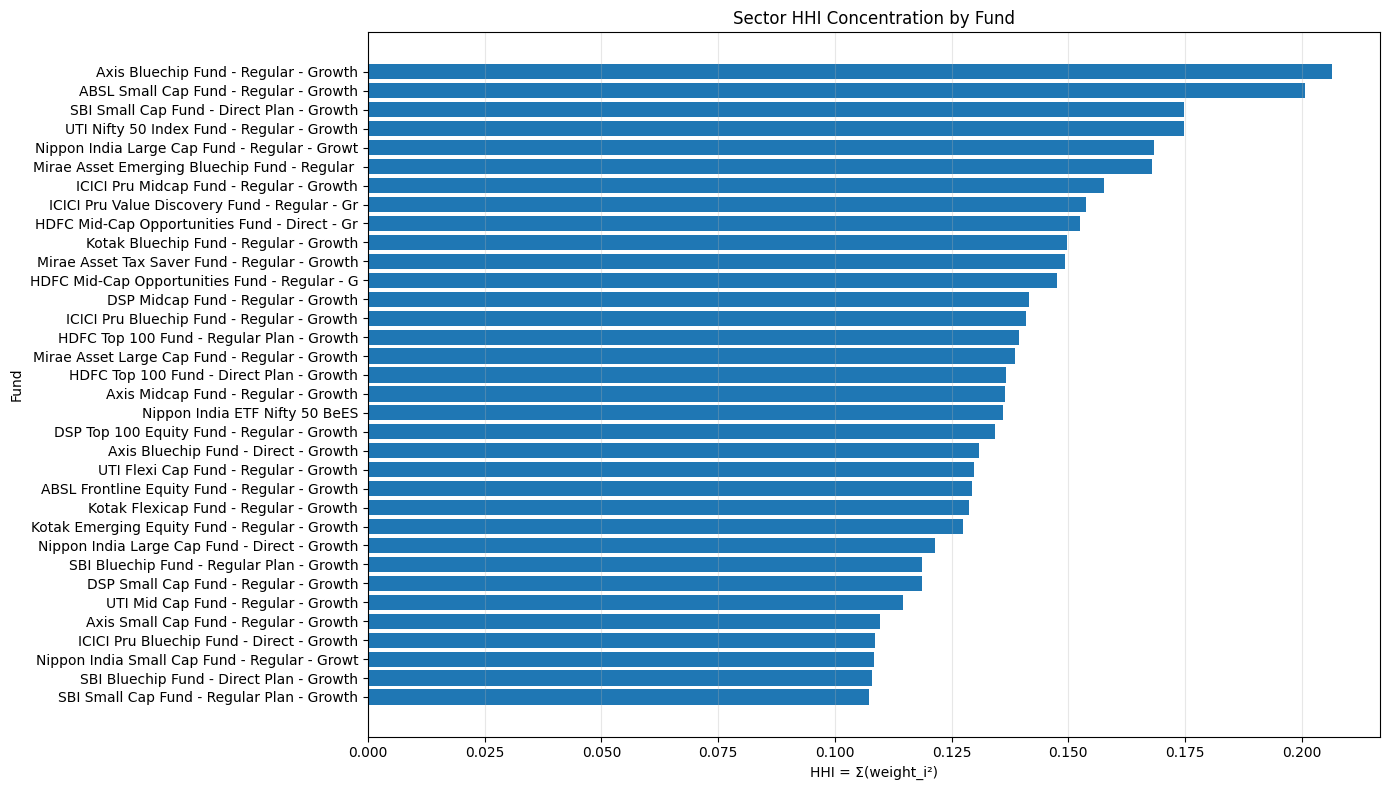

In [13]:
plt.figure(figsize=(14, 8))

plot_hhi = sector_hhi.sort_values("sector_hhi", ascending=True)
plt.barh(plot_hhi["scheme_name"].str[:45], plot_hhi["sector_hhi"])

plt.title("Sector HHI Concentration by Fund")
plt.xlabel("HHI = Σ(weight_i²)")
plt.ylabel("Fund")
plt.grid(axis="x", alpha=0.3)

savefig("sector_hhi_concentration.png")

In [14]:
print("Advanced analytics completed.")
print("Key deliverables:")
print(OUT_DIR / "var_cvar_report.csv")
print(OUT_DIR / "recommender.py")
print(CHART_DIR / "rolling_sharpe_chart.png")
print(OUT_DIR / "Advanced_Analytics.ipynb")

Advanced analytics completed.
Key deliverables:
/Users/nischayaggarwal/Internship 1/reports/var_cvar_report.csv
/Users/nischayaggarwal/Internship 1/reports/recommender.py
/Users/nischayaggarwal/Internship 1/reports/rolling_sharpe_chart.png
/Users/nischayaggarwal/Internship 1/reports/Advanced_Analytics.ipynb
